In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
fp1a = 'data/chlorophyll/chl_depth_mean.nc'
ds1a = xr.open_dataset(fp1a)
chl_mean = ds1a["chl"].mean(dim="time")     # Average chl over the entire dataset
chl_mean = chl_mean.clip(min=1e-4)          # Clip to remove negatives

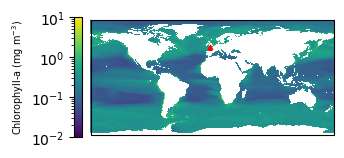

In [2]:
fig, ax = plt.subplots(figsize=(3.25, 2), subplot_kw={"projection": ccrs.PlateCarree()})

norm = mcolors.LogNorm(vmin=0.01, vmax=10)
p = chl_mean.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    rasterized=True, norm=norm, add_colorbar=False
)

# Add WCO for time series context
lon, lat = -4.217, 50.25
ax.scatter(lon, lat, transform=ccrs.PlateCarree(),
           color='red', marker='^', s=10)

fig.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.05)
cbar_ax = fig.add_axes([0.15, 0.2, 0.025, 0.6])
cbar = fig.colorbar(p, cax=cbar_ax)
cbar.set_label(r"Chlorophyll-a (mg m$^{-3}$)", size=7)
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.tick_left()
plt.savefig('figures/chlorophyll_map.png', dpi=600)
plt.savefig('figures/chlorophyll_map.pdf', dpi=600)